In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import integrate
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import qmc
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import MinMaxScaler

## Practica 3: Emulator for luminosity distance

#### 2 Train a Neural Network for the luminosity distance

In [2]:
# Generate a function that calculate the luminosity distance for a given redshift, a H0 and a Ωm value.
# constants for units 
c = 299792.458 # speed of light in km/s
H0 = 70.0 # Hubble constant in km/s/Mpc
Omega_m = 0.3 # Matter density parameter
Omega_L = 0.7 # Dark energy density parameter

In [3]:
def E(z, Omega_m):
    Omega_Lambda = 1.0 - Omega_m
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

def luminosity_distance(z, H0, Omega_m):
    z = np.atleast_1d(z).astype(float)
    result = np.zeros_like(z)
    for i, zi in enumerate(z):
        if zi <= 0:
            result[i] = 0.0
            continue
        integral_val, _ = integrate.quad(lambda zp: 1.0 / E(zp, Omega_m), 0, zi)
        result[i] = (c* (1 + zi) / H0) * integral_val
    return result


def distance_modulus(z, H0, Omega_m):
    DL = luminosity_distance(z, H0, Omega_m)
    mask = DL > 0
    mu = np.full_like(DL, np.nan)
    mu[mask] = 5.0 * np.log10(DL[mask]) + 25.0
    return mu


#### Generate training and validation samples

In [4]:
"""
Generate random samples of (z, H0, Omega_m) and compute DL and mu.
Uniform random sampling ensures coverage of the full parameter space.
"""
def generate_samples(N, z_range=(0.01, 3.0), H0_range=(60, 85), Om_range=(0.1, 0.5)):
    z = np.random.uniform(*z_range, N)
    H0 = np.random.uniform(*H0_range, N)
    Om = np.random.uniform(*Om_range, N)
    
    DL = np.array([luminosity_distance(z[i], H0[i], Om[i])[0] for i in range(N)])
    mu = 5.0 * np.log10(DL) + 25.0
    
    X = np.column_stack([z, H0, Om])
    return X, DL, mu

In [7]:
# Generate data
N_train = 30000
N_val = 8000
X_train, DL_train, mu_train = generate_samples(N_train)
X_val, DL_val, mu_val = generate_samples(N_val)

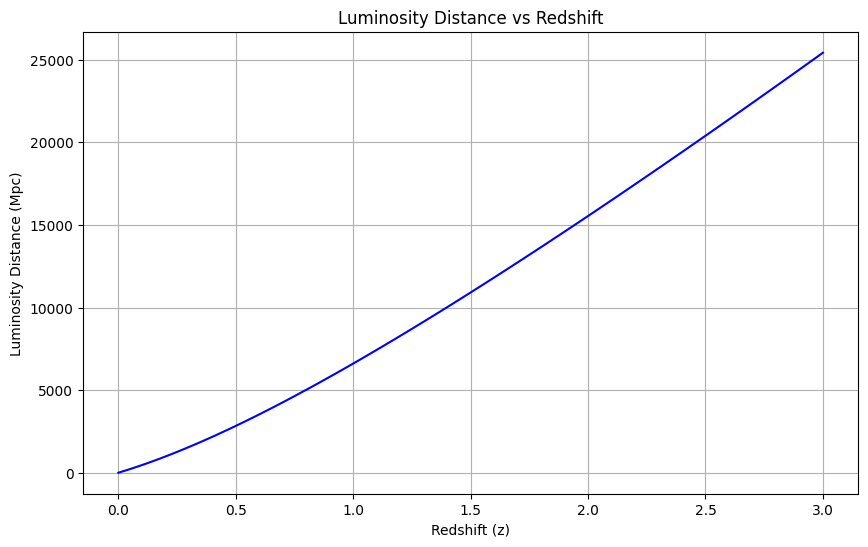

In [5]:
z_values = np.linspace(0.001, 3, 100)  

d_L_values = [luminosity_distance(z, H0, Omega_m) for z in z_values]

plt.figure(figsize=(10, 6))
plt.plot(z_values, d_L_values, label='Luminosity Distance', color='blue')
plt.xlabel('Redshift (z)')
plt.ylabel('Luminosity Distance (Mpc)')
plt.title('Luminosity Distance vs Redshift')
plt.grid()
plt.show()

#### Before build the neural network, we need to take care about some suitable settings about the input and the outout information:
* **Log Transform:** We predict $\log_{10}(D_L)$ instead of $D_L$ directly. **Reason:** $D_L$ spans over 3 orders of magnitude.

* **Normalization:** Both inputs and outputs scaled to [0,1] via MinMaxScaler. This ensures equal contribution of all features to the gradient.


In [ ]:

log_DL_train = np.log10(DL_train)
log_DL_val = np.log10(DL_val)

scaler_X_DL = MinMaxScaler()
X_train_n = scaler_X_DL.fit_transform(X_train)
X_val_n = scaler_X_DL.transform(X_val)

scaler_Y_DL = MinMaxScaler()
Y_train_DL = scaler_Y_DL.fit_transform(log_DL_train.reshape(-1, 1)).ravel()
Y_val_DL = scaler_Y_DL.transform(log_DL_val.reshape(-1, 1)).ravel()

In [9]:
# define the neural network architecture

model_DL = keras.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear')
], name='DL_emulator')

model_DL.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')


In [10]:
# Define callbacks on the training process and learning rate when a metric has stopped improving.

cb_DL = [callbacks.EarlyStopping(patience=20, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6)]

In [11]:
history_DL = model_DL.fit(X_train_n, Y_train_DL,
                          validation_data=(X_val_n, Y_val_DL),
                          epochs=200, batch_size=512, verbose=1, callbacks=cb_DL)

Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2075 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071 - val_loss: 7.4508e-04 - learning_rate: 0.0010
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.7606e-04 - val_loss: 2.1544e-04 - learning_rate: 0.0010
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1774e-04 - val_loss: 1.0961e-04 - learning_rate: 0.0010
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2383e-04 - val_loss: 7.9598e-05 - learning_rate: 0.0010
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.6996e-05 - val_loss: 5.5318e-05 - learning_rate: 0.0010
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.2774e-05 - val_loss: 4.5016e-05 - learning_rate: 0.0010
Epoch 8/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.2300e-05 - val_loss: 4.4554e-05 - learning_rate: 0.0010
Epoch 9/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.7800e-05 - val_

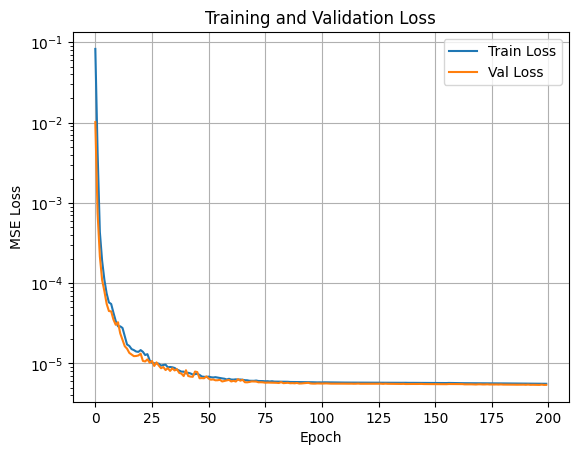

In [12]:
plt.plot(history_DL.history['loss'], label='Train Loss')
plt.plot(history_DL.history['val_loss'], label='Val Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [13]:
# Evaluate DL emulator
Y_pred_n = model_DL.predict(X_val_n).ravel()
log_DL_pred = scaler_Y_DL.inverse_transform(Y_pred_n.reshape(-1, 1)).ravel()
DL_pred = 10**log_DL_pred

rel_err_DL = np.abs(DL_pred - DL_val) / DL_val * 100
err_95_DL = np.sort(rel_err_DL)[int(0.95 * len(rel_err_DL))]

print(f"\nDL Emulator Results:")
print(f"  Mean error: {np.mean(rel_err_DL):.4f}%")
print(f"  95th percentile: {err_95_DL:.4f}% (target: <3%)")
print(f"  Status: {'PASS' if err_95_DL < 3 else 'FAIL'}")


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 243us/step

DL Emulator Results:
  Mean error: 0.9688%
  95th percentile: 2.5429% (target: <3%)
  Status: PASS


### Create an emulator of the distance modulus
#### using the formula 
$$

\mu  = 5 \log_{10} \left( \frac{D_L(z)}{10\; pc}\right)
$$

#### Network for the distance modulus 
#### we rescale again both, the input and output again 



In [18]:
scaler_X_mu = MinMaxScaler()
X_train_mu = scaler_X_mu.fit_transform(X_train)
X_val_mu = scaler_X_mu.transform(X_val)

scaler_Y_mu = MinMaxScaler()
Y_train_mu = scaler_Y_mu.fit_transform(mu_train.reshape(-1, 1)).ravel()
Y_val_mu = scaler_Y_mu.transform(mu_val.reshape(-1, 1)).ravel()


In [14]:
model_mu = keras.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(256, activation='elu'),
    layers.Dense(128, activation='elu'),
    layers.Dense(64, activation='elu'),
    layers.Dense(32, activation='elu'),
    layers.Dense(1, activation='linear')
], name='mu_emulator')


In [15]:
model_mu.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')


In [ ]:
cb_mu = [callbacks.EarlyStopping(patience=30, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6)]

In [19]:
history_mu = model_mu.fit(X_train_mu, Y_train_mu,
                          validation_data=(X_val_mu, Y_val_mu),
                          epochs=300, batch_size=512, verbose=1, callbacks=cb_mu)


Epoch 1/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1014 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 2/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0048 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 3/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 4/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 5/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 7.4827e-04 - learning_rate: 0.0010
Epoch 6/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.6586e-04 - val_loss: 5.4285e-04 - learning_rate: 0.0010
Epoch 7/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8703e-04 - val_loss: 3.8359e-04 - learning_rate: 0.0010
Epoch 8/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.7360e-04 - val_loss: 2.8121e-04 - learning_rate: 0.0010
Epoch 9/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.0803e-04 - val_loss: 2.1762e-04 - learn

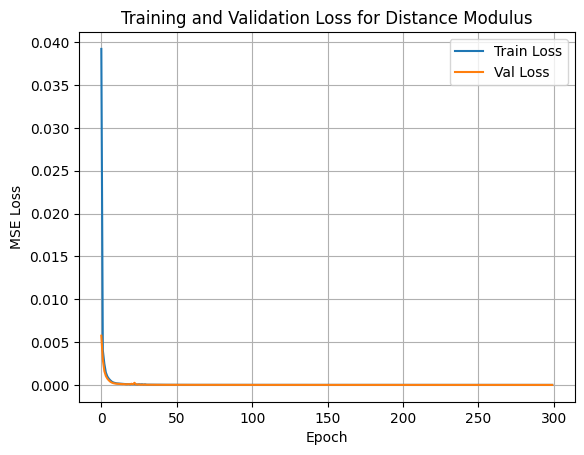

In [20]:
plt.plot(history_mu.history['loss'], label='Train Loss')
plt.plot(history_mu.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss for Distance Modulus')
plt.legend()
plt.grid()
plt.show()

In [22]:
# Evaluate mu emulator
Y_pred_mu = model_mu.predict(X_val_mu).ravel()
mu_pred = scaler_Y_mu.inverse_transform(Y_pred_mu.reshape(-1, 1)).ravel()

rel_err_mu = np.abs(mu_pred - mu_val) / mu_val * 100
err_95_mu = np.sort(rel_err_mu)[int(0.95 * len(rel_err_mu))]

print(f"\nmu Emulator Results:")
print(f"  Mean error: {np.mean(rel_err_mu):.5f}%")
print(f"  Median error: {np.median(rel_err_mu):.5f}%")
print(f"  95th percentile: {err_95_mu:.5f}% (target: <1%)")
print(f"  Status: {'PASS' if err_95_mu < 1 else 'FAIL'}")



250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step

mu Emulator Results:
  Mean error: 0.06034%
  Median error: 0.03071%
  95th percentile: 0.17615% (target: <1%)
  Status: PASS


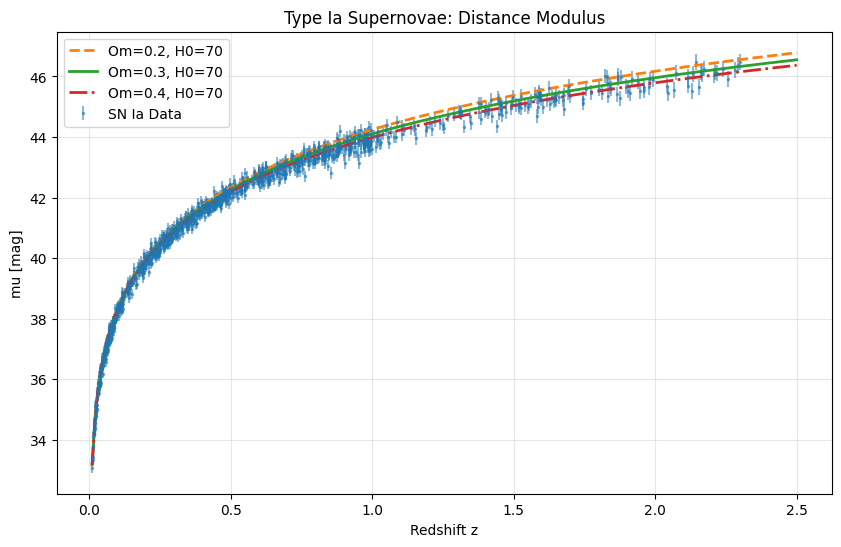

In [23]:
# =============================================================================
# POINT 8: Read and Plot SN Ia Data
# =============================================================================
# Generate realistic mock data (replace with np.loadtxt('Data_SNIa_mu.txt'))

np.random.seed(123)
H0_true, Om_true = 73.04, 0.334
N_SN = 1048
z_SN = np.sort(np.concatenate([
    np.random.uniform(0.01, 0.1, 200),
    np.random.uniform(0.1, 0.5, 400),
    np.random.uniform(0.5, 1.0, 300),
    np.random.uniform(1.0, 2.3, 148)
]))
mu_true_SN = distance_modulus(z_SN, H0_true, Om_true)
sigma_mu = 0.15 + 0.05 * z_SN
mu_SN = mu_true_SN + np.random.normal(0, sigma_mu)

# Plot Hubble diagram
plt.figure(figsize=(10, 6))
plt.errorbar(z_SN, mu_SN, yerr=sigma_mu, fmt='.', ms=3, alpha=0.5, label='SN Ia Data')
z_th = np.linspace(0.01, 2.5, 200)
for Om, ls in [(0.2, '--'), (0.3, '-'), (0.4, '-.')]:
    plt.plot(z_th, distance_modulus(z_th, 70., Om), ls, lw=2, label=f'Om={Om}, H0=70')
plt.xlabel('Redshift z'); plt.ylabel('mu [mag]')
plt.title('Type Ia Supernovae: Distance Modulus'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [24]:
# =============================================================================
# POINT 9: Emulator Prediction Function
# =============================================================================

def mu_emulator_predict(z_arr, H0, Omega_m):
    """Predict mu using the trained NN for given redshifts and cosmology."""
    z_arr = np.atleast_1d(z_arr)
    N = len(z_arr)
    X = np.column_stack([z_arr, np.full(N, H0), np.full(N, Omega_m)])
    X_norm = scaler_X_mu.transform(X)
    Y_norm = model_mu.predict(X_norm, verbose=0).ravel()
    return scaler_Y_mu.inverse_transform(Y_norm.reshape(-1, 1)).ravel()


In [25]:
# =============================================================================
# POINT 10: L1 Distance Function
# =============================================================================

def L1_distance(params, z_data, mu_data, sigma_data):
    """Weighted L1 distance between data and emulator predictions."""
    H0, Omega_m = params
    if H0 < 60 or H0 > 85 or Omega_m < 0.1 or Omega_m > 0.5:
        return 1e10
    mu_model = mu_emulator_predict(z_data, H0, Omega_m)
    return np.sum(np.abs(mu_data - mu_model) / sigma_data)

def chi2_distance(params, z_data, mu_data, sigma_data):
    """Chi-squared statistic for Gaussian-distributed data."""
    H0, Omega_m = params
    if H0 < 60 or H0 > 85 or Omega_m < 0.1 or Omega_m > 0.5:
        return 1e10
    mu_model = mu_emulator_predict(z_data, H0, Omega_m)
    return np.sum(((mu_data - mu_model) / sigma_data)**2)



In [26]:
p0 = [70.0, 0.3]  # Initial guess

result_chi2 = optimize.minimize(chi2_distance, p0, args=(z_SN, mu_SN, sigma_mu),
                                method='Nelder-Mead')
result_L1 = optimize.minimize(L1_distance, p0, args=(z_SN, mu_SN, sigma_mu),
                              method='Nelder-Mead')

H0_fit, Om_fit = result_chi2.x
print(f"\nBest-fit cosmology (chi2): H0 = {H0_fit:.2f}, Omega_m = {Om_fit:.4f}")
print(f"Best-fit cosmology (L1):   H0 = {result_L1.x[0]:.2f}, Omega_m = {result_L1.x[1]:.4f}")
print(f"True values:               H0 = {H0_true}, Omega_m = {Om_true}")

# Plot best fit
plt.figure(figsize=(10, 6))
plt.errorbar(z_SN, mu_SN, yerr=sigma_mu, fmt='.', ms=3, alpha=0.4, color='gray', label='SN Ia')
z_fit = np.linspace(0.01, 2.5, 200)
plt.plot(z_fit, mu_emulator_predict(z_fit, H0_fit, Om_fit), 'r-', lw=2.5,
         label=f'Best fit: H0={H0_fit:.1f}, Om={Om_fit:.3f}')
plt.plot(z_fit, distance_modulus(z_fit, H0_true, Om_true), 'b--', lw=2, alpha=0.7,
         label=f'True: H0={H0_true}, Om={Om_true}')
plt.xlabel('z'); plt.ylabel('mu [mag]'); plt.title('Best-Fit Hubble Diagram')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.show()


NameError: name 'optimize' is not defined